# People Series Poster Demo

This notebook renders ordered people-series posters, such as U.S. Presidents, UK monarchs, Nobel Prize winners, or future sports-award providers.

Phase 2 keeps this notebook intentionally thin. The app function handles the workflow: provider records, generic label/image repair, `SeriesRecord` creation, keyed image resolution, poster rendering, and a standard `ArtifactResult`.


## Setup


In [1]:
from notebook_bootstrap import (
    display_image,
    image_files,
    init_notebook,
)

ctx, reg = init_notebook()

REPO_ROOT = ctx.repo_root
PROJECT_ROOT = ctx.project_root
SRC_ROOT = ctx.src_root
PACKAGE_SRC = ctx.package_src
CACHE = ctx.cache
RESULTS = ctx.results


/opt/anaconda3/envs/ai_py312/lib/python3.12/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "


'NoneType' object has no attribute 'cadam32bit_grad_fp32'
Repo root: /Users/douglasdaly/GitHub/Generative-AI
Project root: /Users/douglasdaly/GitHub/Generative-AI
Package src: /Users/douglasdaly/GitHub/Generative-AI/src/genai_demos/agentic_multimodal
Cache: /Users/douglasdaly/GitHub/Generative-AI/src/genai_demos/agentic_multimodal/cache
Results: /Users/douglasdaly/GitHub/Generative-AI/results/agentic_multimodal
Legacy artifact roots: ['/Users/douglasdaly/GitHub/Generative-AI/Projects/agentic-multimodal/artifacts']
Legacy cache roots: ['/Users/douglasdaly/GitHub/Generative-AI/Projects/agentic-multimodal/cache']


In [2]:
from pprint import pprint

from agentic_multimodal.apps import run_people_series_poster


## Demo parameters

Choose one example and rerun the app cell. The downstream workflow should not need provider-specific notebook logic.

For real people, the default path prefers sourced images and keyed cache reuse. Generated portraits are intentionally opt-in and should not be the normal path for public figures.


In [3]:
SERIES_EXAMPLES = {
    "potus_terms": {
        "series_key": "potus",
        "title": "U.S. Presidents - Terms",
        "mode": "per_term",
        "cols": 6,
        "expect_open_current_term": True,
    },
    "nobel_physics": {
        "series_key": "nobel_physics",
        "title": "Nobel Prize in Physics - Laureates",
        "mode": "per_person_auto",
        "cols": 12,
        "expect_open_current_term": False,
    },
    "uk_monarchs": {
        "series_key": "monarchs_eng_gb_uk",
        "title": "Monarchs of England/GB/UK - Terms",
        "mode": "per_term",
        "cols": 8,
        "expect_open_current_term": True,
    },
    "future_nba_mvp": {
        "note": "STUB: requires adding an NBA MVP provider that emits Person records."
    },
}

EXAMPLE = "potus_terms"
config = SERIES_EXAMPLES[EXAMPLE]

SERIES_KEY = config["series_key"]
POSTER_TITLE = config["title"]
MODE = config["mode"]
COLS = config["cols"]
EXPECT_OPEN_CURRENT_TERM = config["expect_open_current_term"]

IMAGE_SCOPE = "entity"  # "entity" or "record"
CACHE_POLICY = "reuse_then_source"
RUN_IMAGE_GENERATION = False
FAIL_ON_MISSING_IMAGES = True

PEOPLE_IMAGE_DIR = RESULTS / "people" / SERIES_KEY / MODE
PEOPLE_POSTER_PATH = RESULTS / "posters" / f"poster_{SERIES_KEY}_{MODE}.webp"

print("Example:", EXAMPLE)
print("Series key:", SERIES_KEY)
print("Mode:", MODE)
print("Image directory:", PEOPLE_IMAGE_DIR)
print("Poster path:", PEOPLE_POSTER_PATH)
print("Cache policy:", CACHE_POLICY)


Example: potus_terms
Series key: potus
Mode: per_term
Image directory: /Users/douglasdaly/GitHub/Generative-AI/results/agentic_multimodal/people/potus/per_term
Poster path: /Users/douglasdaly/GitHub/Generative-AI/results/agentic_multimodal/posters/poster_potus_per_term.webp
Cache policy: reuse_then_source


## Run the app workflow

`run_people_series_poster(...)` returns an `ArtifactResult`. The notebook displays the artifact and keeps trace/cache details available for inspection without duplicating the orchestration logic.


people_series_poster: U.S. Presidents - Terms (created) -> /Users/douglasdaly/GitHub/Generative-AI/results/agentic_multimodal/posters/poster_potus_per_term.webp


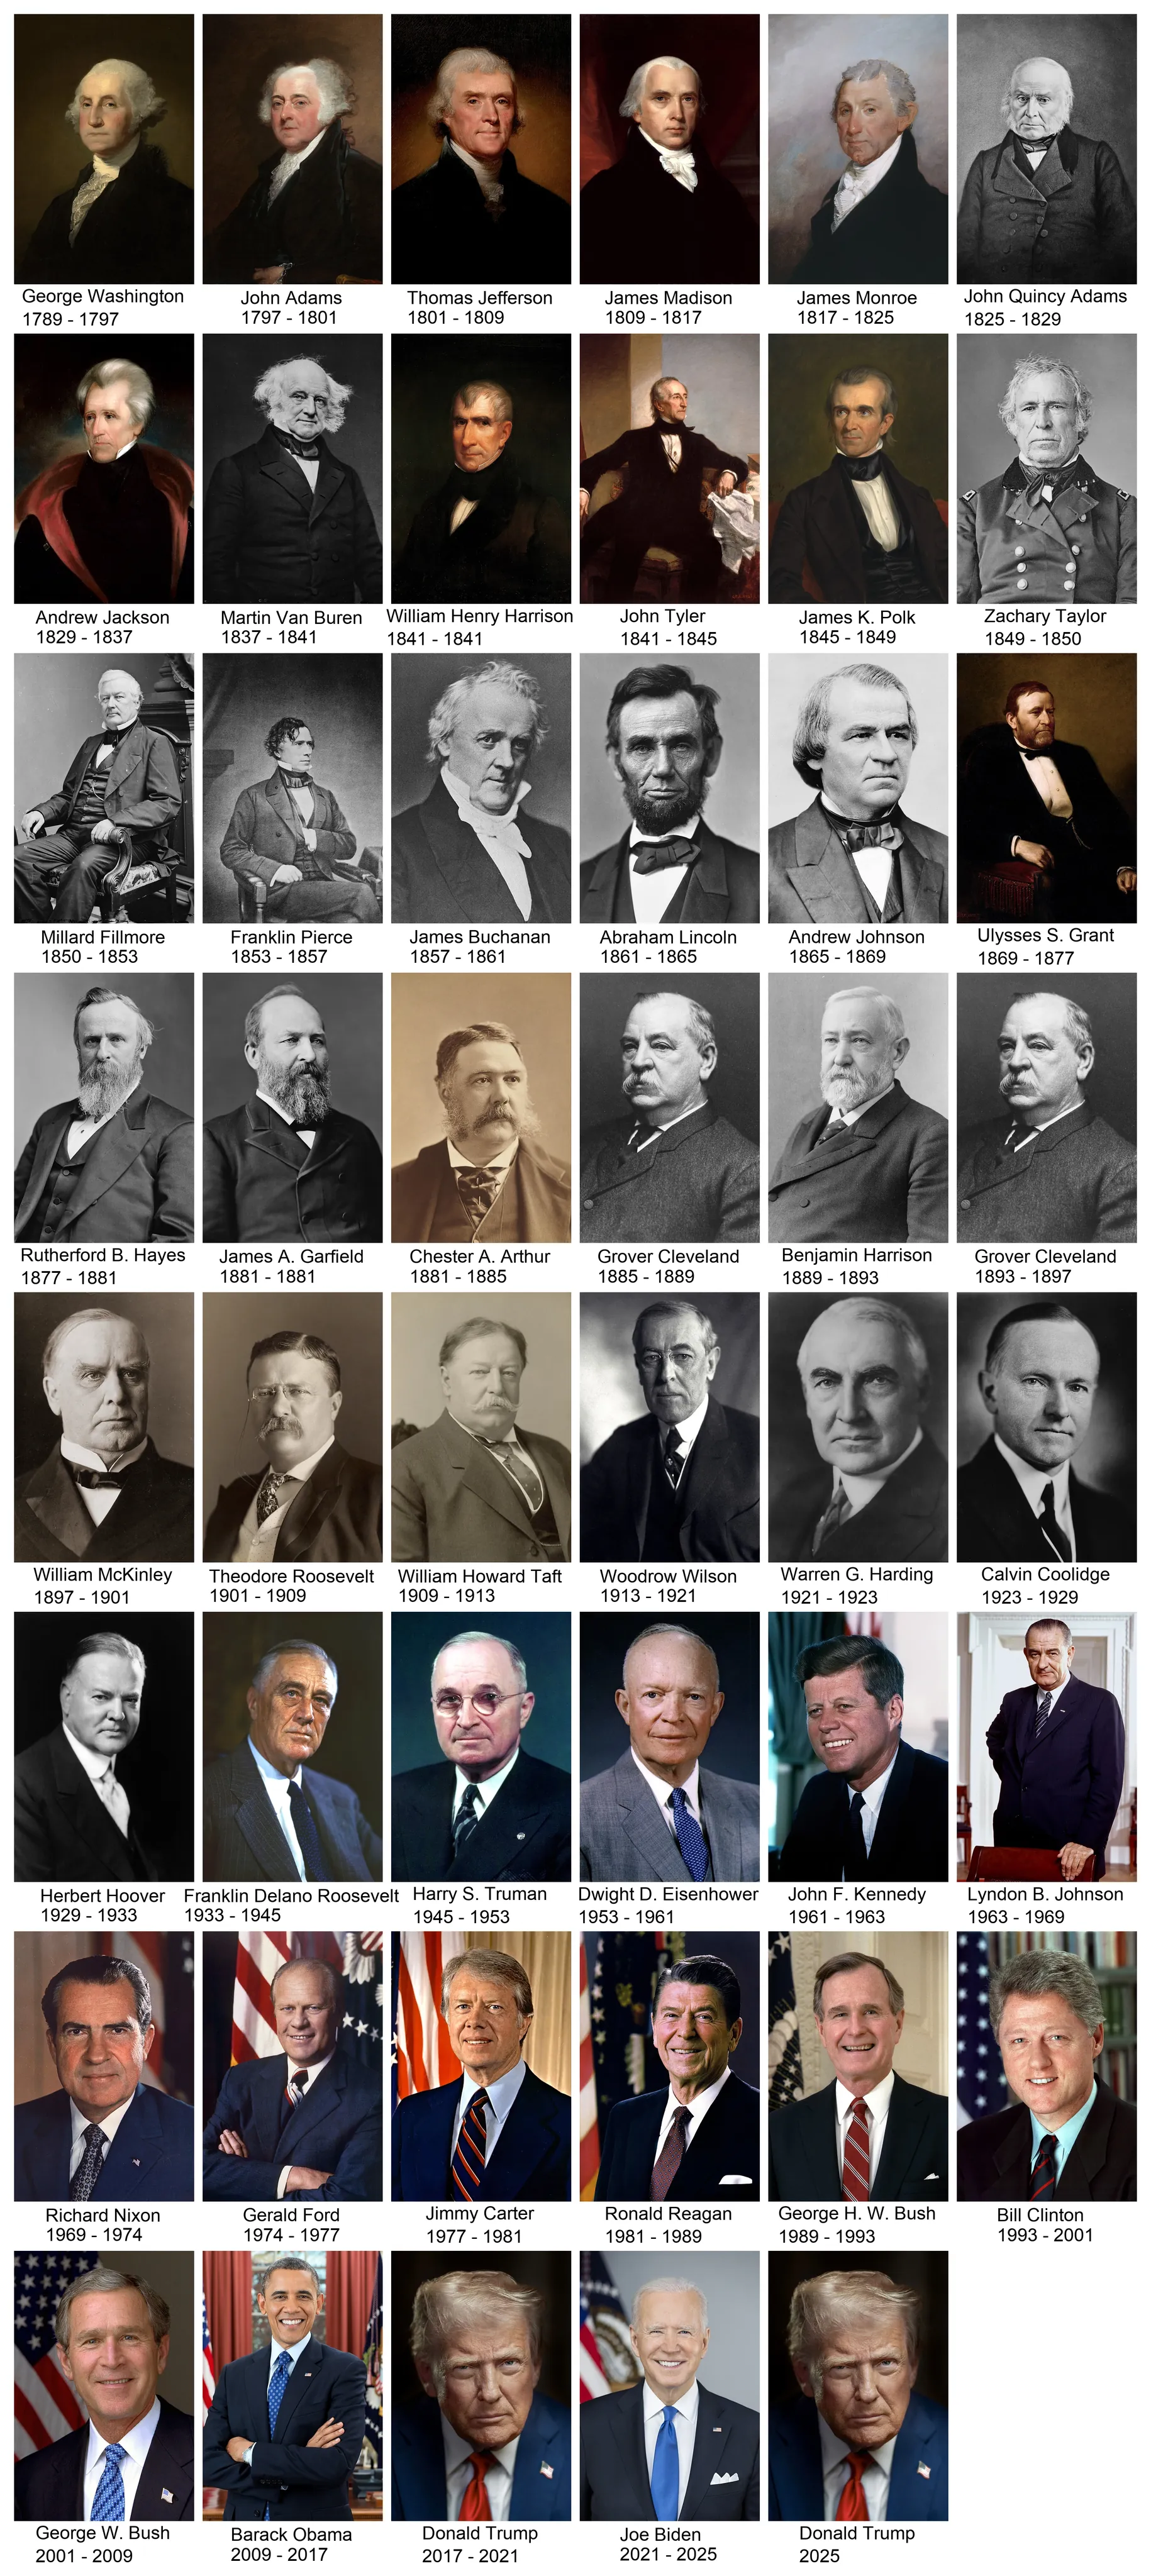

In [4]:
result = run_people_series_poster(
    reg=reg,
    results_dir=RESULTS,
    series_key=SERIES_KEY,
    title=POSTER_TITLE,
    mode=MODE,
    cols=COLS,
    image_scope=IMAGE_SCOPE,
    cache_policy=CACHE_POLICY,
    run_image_generation=RUN_IMAGE_GENERATION,
    expect_open_current_term=EXPECT_OPEN_CURRENT_TERM,
    fail_on_missing_images=FAIL_ON_MISSING_IMAGES,
    outpath=PEOPLE_POSTER_PATH,
    image_dir=PEOPLE_IMAGE_DIR,
)

print(result.summary())
display_image(result.path)


## Inspect result metadata

The app result exposes trace and cache details for teaching/debugging. This replaces the older notebook cells that manually printed provider rows, image resolver output, and manifest paths.


In [5]:
pprint(result.to_dict())


{'cache_hits': {'image_assets_reused': 45},
 'cache_misses': {'image_assets_downloaded': 0,
                  'image_missing': 0,
                  'image_placeholders': 0},
 'cache_summary': {'assets': 45,
                   'cache_policy': 'reuse_then_source',
                   'downloaded': 0,
                   'missing': 0,
                   'placeholders': 0,
                   'reused': 45},
 'exists': True,
 'kind': 'people_series_poster',
 'path': '/Users/douglasdaly/GitHub/Generative-AI/results/agentic_multimodal/posters/poster_potus_per_term.webp',
 'title': 'U.S. Presidents - Terms',
 'trace': {'expect_open_current_term': True,
           'image_dir': '/Users/douglasdaly/GitHub/Generative-AI/results/agentic_multimodal/people/potus/per_term',
           'image_scope': 'entity',
           'manifest_path': '/Users/douglasdaly/GitHub/Generative-AI/results/agentic_multimodal/people/potus/per_term/manifest.jsonl',
           'mode': 'per_term',
           'people_count': 45,
 

## Optional smoke checks

These checks make sure the app-layer contract is doing what the notebook expects.


In [6]:
assert result.exists
assert result.kind == "people_series_poster"
assert result.trace["series_key"] == SERIES_KEY
assert result.trace["record_count"] > 0
assert result.cache_summary["assets"] > 0

if FAIL_ON_MISSING_IMAGES:
    assert result.cache_summary["missing"] == 0

print("People-series app smoke checks passed.")


People-series app smoke checks passed.


## Implementation notes

- The notebook calls one app function instead of manually orchestrating each step.
- People, award, and office-holder posters use the generic `SeriesRecord` contract.
- Display labels are repaired and validated before rendering.
- Images are resolved by stable `image_key`, not sorted file order.
- Repeated people can have multiple records while sharing one image asset.
- The app prefers sourced portraits for real people.
- Rate limits and missing images are treated as data/source issues, not silently hidden.
- The same poster renderer is shared with the animal poster demo.
